# Notebook 2: Preprocessing & Feature Selection

**Input:** `kidney_cells_clean.csv` or `kidney_cells_top_classes.csv` (from Notebook 1)  
**Output:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

---

## What this notebook does
1. Load the cleaned dataset
2. Separate gene expression features and cell type labels
3. Take a stratified sample of 20,000 cells
4. Split into 80% training and 20% test sets
5. Feature reduction — all steps fit on training data only:
   - Remove zero-variance genes
   - Scale with StandardScaler
   - Remove near-zero-variance genes with VarianceThreshold
   - Use RFE (Recursive Feature Elimination) with a LinearSVC ranker to select the most informative genes
6. Apply SMOTE to the training split to balance class sizes
7. Save the four output files

---

**Data Leakage:**  
All preprocessing steps are **fit on the training set only**, then applied to both sets. Fitting on the full data before splitting would leak test set information into the model and produce unrealistically high evaluation scores.

## 1. Mount Google Drive

This connects the notebook to your Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Configuration

Set `data_dir` to your Google Drive folder.  
Set `INPUT_FILE` to choose between all 22 classes or the top 10 prominent classes only.

The first line installs `imbalanced-learn`, the library that provides SMOTE. It only needs to run once per Colab session. Below that we import all the libraries this notebook needs and set up the key variables. The only line you are likely to need to change is `data_dir` — update it to match the folder on your Google Drive where the dataset is stored. You can also change `input_file` to switch between the full 22-class dataset and the top-10 class subset.

In [2]:
!pip install imbalanced-learn -q

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.svm               import LinearSVC
from sklearn.metrics           import f1_score
from imblearn.over_sampling    import SMOTE

data_dir   = Path('/content/drive/MyDrive/Colab Notebooks/Tisch ML Project')
input_file = 'kidney_cells_top_classes.csv'   # or kidney_cells_clean.csv for all 22 classes
clean_file = data_dir / input_file

metadata_cols = ['Cell_ID', 'nCount_RNA', 'nFeature_RNA',
                 'StudyOrigin_Author', 'percent.mt',
                 'Sex', 'Sampling_Location', 'Age', 'Cell_Labels']
target_col    = 'Cell_Labels'

subset_size = 20_000
test_size   = 0.20
random_seed = 42
vt_threshold = 0.01
null_threshold = 0.90

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## 3. Load Dataset

This reads the CSV file saved by Notebook 1 into a pandas DataFrame and prints a quick summary of how many rows (cells) and columns there are.

In [3]:
print(f'Loading {input_file}...')
df = pd.read_csv(clean_file, low_memory=False)
print('Done.')
print()
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]:,}')
print(f'Classes : {df[target_col].nunique()}')

Loading kidney_cells_top_classes.csv...
Done.

Rows    : 50,218
Columns : 2,367
Classes : 10


## 4. Separate Features and Target

The features (X) are the 2,358 gene expression columns. The target (y) is the `Cell_Labels` column. All 9 metadata columns are excluded from X — cell type is determined by gene expression, not by patient age, sex, or study origin.

We separate the data into two parts: `X` contains every gene expression column (the inputs to the model), and `y` contains the cell type label for each cell (the thing we want to predict). We also print the class distribution so we can see how many cells there are per type.

In [4]:
# All columns that are NOT in the metadata list must be gene expression columns
gene_cols = [c for c in df.columns if c not in metadata_cols]

X = df[gene_cols].copy()
y = df[target_col].copy()

print(f'X shape : {X.shape}  ({X.shape[1]:,} gene columns)')
print(f'y shape : {y.shape}')
print(f'Classes : {y.nunique()}')
print()
print('Class distribution:')
for label, count in y.value_counts().items():
    print(f'  {label:<55}: {count:>6,}  ({count/len(y)*100:.1f}%)')

X shape : (50218, 2358)  (2,358 gene columns)
y shape : (50218,)
Classes : 10

Class distribution:
  Proximal Tubule                                        : 24,848  (49.5%)
  T                                                      :  3,436  (6.8%)
  Ascending Thin Limb                                    :  3,105  (6.2%)
  Thick Ascending Limb                                   :  2,735  (5.4%)
  Myeloid                                                :  2,605  (5.2%)
  Endothelium                                            :  2,378  (4.7%)
  Loop of Henle and Parietal Epithelium                  :  1,843  (3.7%)
  Distal Convoluted Tubule                               :  1,814  (3.6%)


## 5. Stratified Sample

The full dataset has ~50,000 cells in the top-10 subset. We take a stratified sample that preserves class proportions — if Proximal Tubule makes up 49% of the full dataset it will also make up approximately 49% of the sample. This ensures every class is represented in both the training and test sets.

`subset_size` in the configuration cell controls how many cells are sampled. This run used **10,000 cells** (producing a training set of ~7,996 and a test set of ~1,999). Increasing to 20,000 gives rare minority classes more training examples and produces more stable feature rankings.

Two methods are shown. Run only one.

Method A: we define a function that calculates how many cells to take from each class proportionally, then applies it to every class using `groupby`. For example, if Proximal Tubule makes up 49% of the full dataset, we take approximately 9,800 cells of that type for our 20,000-cell sample. This preserves the real class balance rather than flattening it.

In [5]:
# Method A — proportional sampling per class
# For each class: n = subset_size x (class_size / total_size)
# e.g. total=60000, subset=10000, Proximal Tubule=24000 → n = 10000 x (24000/60000) = 4000

# Use index-aligned assignment (not .values) so the label column aligns on index, not position
full_df = X.copy()
full_df[target_col] = y

def sample_group(group):
    n = max(1, int(subset_size * len(group) / len(full_df)))
    return group.sample(n=n, random_state=random_seed)

# Split by cell type, sample each group proportionally, then stack back together.
# target_col is kept inside the grouped df so X_sub and y_sub are always in lockstep.
subset_df = full_df.groupby(target_col, group_keys=False).apply(sample_group)

# Separate features and labels — they came from the same rows so alignment is guaranteed
X_sub = subset_df.drop(columns=[target_col])
y_sub = subset_df[target_col]

print(f'Method A — subset size : {len(X_sub):,} cells')
print(f'           classes     : {y_sub.nunique()}')

Method A — subset size : 19,996 cells
           classes     : 10


/tmp/ipykernel_1470/522100017.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset_df = full_df.groupby(target_col, group_keys=False).apply(sample_group)


**Why is the subset slightly less than 20,000?**

When we calculate the exact proportional share for each cell type, the result is often a decimal number (e.g. 3,720.4 cells). We round down using `int()` so we always take a whole number of cells. Those tiny rounding losses add up across all 10 classes, so the final subset is usually a few cells short of exactly 20,000.

Method B is an alternative way to do the same thing using `train_test_split`. It is commented out — uncomment it and comment out Method A if you prefer this approach. Both methods produce the same result: a stratified 20,000-cell sample.

In [6]:
# Method B — using train_test_split
# Uncomment this block and comment out Method A to use instead.

# _, X_sub, _, y_sub = train_test_split(
#     X, y,
#     test_size=subset_size,
#     random_state=random_seed,
#     stratify=y
# )
# print(f'Method B — subset size : {len(X_sub):,} cells')
# print(f'           classes     : {y_sub.nunique()}')

print('Method B is commented out. Using Method A.')

Method B is commented out. Using Method A.


We print the class proportions in the full dataset and in the sample side by side to confirm they match. If the numbers in the two columns are identical (or differ by at most 0.1%), the stratified sampling worked correctly.

In [7]:
# Double-check that the class proportions in the sample match the full dataset
# Verify class proportions are preserved
full_pct   = y.value_counts(normalize=True).sort_index() * 100
subset_pct = y_sub.value_counts(normalize=True).sort_index() * 100
print('Class proportions — full vs subset:')
print(pd.DataFrame({'Full (%)': full_pct, 'Subset (%)': subset_pct}).round(1).to_string())

Class proportions — full vs subset:
                                       Full (%)  Subset (%)
Cell_Labels                                                
Ascending Thin Limb                         6.2         6.2
Distal Convoluted Tubule                    3.6         3.6
Endothelium                                 4.7         4.7
Loop of Henle and Parietal Epithelium       3.7         3.7
Myeloid                                     5.2         5.2
Proximal Tubule                            49.5        49.5
T                                           6.8         6.8
Thick Ascending Limb                        5.4         5.4


## 6. Train / Test Split

80% of the subset goes to training, 20% to testing. `stratify=y_sub` keeps class proportions equal in both sets. `random_state=42` makes the split reproducible.

We split the sampled cells into a training set (80%) and a test set (20%). The `stratify` argument ensures each set has the same proportion of each cell type. We then print a verification table to confirm this.

In this run the split produced **7,996 training cells** and **1,999 test cells**. The test set is set aside now and will not be used again until we evaluate the final model — using it earlier would give us misleadingly good scores.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_sub
)

print(f'Training set : {X_train.shape[0]:,} cells')
print(f'Test set     : {X_test.shape[0]:,} cells')
print(f'Features     : {X_train.shape[1]:,} gene columns')
print()

train_pct   = y_train.value_counts(normalize=True).sort_index() * 100
test_pct    = y_test.value_counts(normalize=True).sort_index() * 100
split_check = pd.DataFrame({'Train (%)': train_pct, 'Test (%)': test_pct}).round(1)
print('Stratification check:')
print(split_check.to_string())

Training set : 15,996 cells
Test set     : 4,000 cells
Features     : 2,358 gene columns

Stratification check:
                                       Train (%)  Test (%)
Cell_Labels                                               
Ascending Thin Limb                          6.2       6.2
Distal Convoluted Tubule                     3.6       3.6
Endothelium                                  4.7       4.7
Loop of Henle and Parietal Epithelium        3.7       3.7
Myeloid                                      5.2       5.2
Proximal Tubule                             49.5      49.5
T                                            6.8       6.8
Thick Ascending Limb                         5.4       5.4


## 7. Feature Reduction

We have 2,358 gene expression features. Many will be uninformative. We reduce them in five steps, all fitted on training data only.

| Step | Method | Purpose |
|---|---|---|
| 1 | Zero-variance removal | Remove genes that are exactly 0 in every training cell |
| 2 | High-null removal | Remove genes where more than 90% of values are missing |
| 3 | StandardScaler | Normalise expression values to mean=0, std=1 |
| 4 | VarianceThreshold | Remove genes with near-zero variance after scaling |
| 5 | RFE with LinearSVC (`step=0.2`) | Iteratively remove the least important genes (20% per round) until the optimal number remains |

**Why RFE?** RFE works by repeatedly training a linear model on the current feature set, ranking each gene by the magnitude of its coefficient, removing the least important genes, and repeating until `k` genes remain.
- **Model-driven** — gene importance is measured by actual predictive contribution to a linear classifier, not just a statistical test
- **Iterative** — genes are evaluated in the context of all other remaining genes, not independently
- **Fast** — using `step=0.2` removes 20% of features per round rather than one at a time, keeping each RFE call practical on CPU

**Why LinearSVC inside RFE?** LinearSVC exposes `coef_` — the weight each gene receives in the decision boundary. RFE uses these weights to rank genes: genes with small absolute coefficients contribute little and are eliminated first. LinearSVC is fast on high-dimensional data and is the standard estimator for RFE in genomics and text classification. The genes it selects are then passed to KNN and SVM for the actual classification.

### Step 1 — Remove Zero-Variance Genes

A gene with zero variance has the exact same value in every training cell. It carries no information — the model cannot learn anything from a feature that never changes.

We calculate the variance of each gene across all training cells. Any gene that has exactly zero variance — meaning every cell in the training set has the exact same value for that gene — is removed. These genes carry no information at all, so including them would just slow the model down without helping it.

In [9]:
train_variance = X_train.var()
zero_var_cols  = train_variance[train_variance == 0].index.tolist()

print(f'Genes with zero variance : {len(zero_var_cols):,}')

if len(zero_var_cols) > 0:
    X_train = X_train.drop(columns=zero_var_cols)
    X_test  = X_test.drop(columns=zero_var_cols)
    print(f'Removed. Genes remaining : {X_train.shape[1]:,}')
else:
    print(f'None removed. Genes remaining : {X_train.shape[1]:,}')
n_after_zero_var = X_train.shape[1]  # track for summary cell


Genes with zero variance : 22
Removed. Genes remaining : 2,336


### Step 2 — Remove High-Null Genes

Any gene column where more than 90% of values are missing (NaN) is removed. A column with that many missing values is too sparse to be useful — you cannot reliably impute or learn from a feature that is absent in almost all cells.

In this dataset the gene expression columns store undetected genes as 0 rather than NaN, so we expect no columns to be removed here. The step is included because it is the correct thing to check, and because it mirrors the same step in the Sepsis preprocessing pipeline.

We check each gene column for missing values. Any gene where more than 90% of training cells have no recorded value is removed. In this dataset the gene expression columns have no missing values at all (undetected genes are stored as 0, not NaN), so this step typically removes nothing — but it is good practice to include it.

In [10]:
# Calculate null % per gene column on the training set only
null_pct      = X_train.isnull().mean()
high_null_cols = null_pct[null_pct > null_threshold].index.tolist()

print(f'Null threshold : {null_threshold * 100:.0f}%')
print(f'Genes with >{null_threshold * 100:.0f}% null values : {len(high_null_cols):,}')

if len(high_null_cols) > 0:
    X_train = X_train.drop(columns=high_null_cols)
    X_test  = X_test.drop(columns=high_null_cols)
    print(f'Removed. Genes remaining : {X_train.shape[1]:,}')
else:
    print('None removed. Gene expression columns contain no null values.')
    print(f'Genes remaining : {X_train.shape[1]:,}')
n_after_null = X_train.shape[1]  # track for summary cell


Null threshold : 90%
Genes with >90% null values : 0
None removed. Gene expression columns contain no null values.
Genes remaining : 2,336


### Step 3 — StandardScaler

StandardScaler rescales each gene's values to have a mean of 0 and standard deviation of 1 across all training cells. This ensures that genes with naturally larger count values do not dominate the variance calculation in the next step.

Fitted on training set only (`fit_transform`), then applied to the test set (`transform`).

StandardScaler rescales every gene so it has a mean of 0 and a standard deviation of 1 across the training cells. This is important for distance-based models like KNN and kernel-based models like SVM, because without scaling a gene that happens to have large raw counts would dominate the distance calculation over genes with small counts, even if the smaller-count gene is actually more informative. We fit the scaler on the training data only, then apply the same transformation to the test data — this prevents the test set from influencing how the scaling is calculated.

In [11]:
current_cols = X_train.columns.tolist()

scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=current_cols, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=current_cols, index=X_test.index)

print('StandardScaler applied.')
print(f'Mean of first gene (train) : {X_train_sc.iloc[:, 0].mean():.4f}  (should be ~0)')
print(f'Std  of first gene (train) : {X_train_sc.iloc[:, 0].std():.4f}  (should be ~1)')

StandardScaler applied.
Mean of first gene (train) : -0.0000  (should be ~0)
Std  of first gene (train) : 1.0000  (should be ~1)


### Step 4 — VarianceThreshold

After scaling, genes that are near-zero in most cells will still have very low variance. `VarianceThreshold` removes any gene whose variance across all training cells falls below the threshold of 0.01.

`vt.get_support()` returns a boolean array — `True` for genes that pass, `False` for genes removed. This same mask is applied to both training and test sets.

VarianceThreshold removes genes whose variance (after scaling) falls below 0.01. Even though we already removed genes with exactly zero variance, some genes will have very small but non-zero variance — they barely change from cell to cell and are unlikely to be useful for classification. Setting the threshold at 0.01 after StandardScaler is a gentle filter: because the scaler normalises all genes to std ≈ 1, a threshold of 0.01 catches only genes that are still nearly constant after normalisation.

In [12]:
vt = VarianceThreshold(threshold=vt_threshold)
vt.fit(X_train_sc)

# vt.get_support() → [True, False, True, True, False, ...]  (True = keep)
vt_support   = vt.get_support()
kept_cols    = X_train_sc.columns[vt_support].tolist()
removed_cols = X_train_sc.columns[~vt_support].tolist()

X_train_vt = X_train_sc[kept_cols]
X_test_vt  = X_test_sc[kept_cols]

print(f'VarianceThreshold (threshold = {vt_threshold})')
print(f'Before : {X_train_sc.shape[1]:,} genes')
print(f'Removed: {len(removed_cols):,} genes')
print(f'After  : {len(kept_cols):,} genes')

VarianceThreshold (threshold = 0.01)
Before : 2,336 genes
Removed: 0 genes
After  : 2,336 genes


### Step 5 — RFE (Recursive Feature Elimination): Finding the Optimal Number of Features

We use **RFE (Recursive Feature Elimination)** with a **LinearSVC** estimator to iteratively remove the least informative genes and sweep across candidate values of k to find the optimal number of features to keep.

**How it works:**
1. For each candidate k (starting at 50% of features, halving each time), run RFE with `n_features_to_select=k`
2. RFE fits a LinearSVC on the current feature set, ranks genes by the magnitude of their coefficients, and removes the least important genes in chunks (`step=0.2` removes 20% of remaining features per round instead of one at a time)
3. Evaluate the selected k genes using **3-fold cross-validation on the training set only** — the test set is never touched
4. Pick the k with the highest cross-validated weighted F1 score

**Why LinearSVC inside RFE?** LinearSVC trains a linear support vector machine and exposes `coef_` — the weight each gene gets in the decision boundary. RFE uses these weights to rank genes: genes with small absolute coefficients contribute little to the model and are eliminated first. LinearSVC is fast on high-dimensional data and is the standard choice for RFE in text and genomics applications.

**Why `step=0.2`?** By default RFE removes one feature per round, which would mean over 1,000 rounds for 2,300+ features. Setting `step=0.2` removes 20% of the remaining features each round, reducing the number of rounds to roughly 9–10 per k value — making each RFE call complete in a reasonable time while still finding a good feature subset.

We test a range of values of k (starting at 50% of the remaining genes and halving each time). For each k, we run RFE with a LinearSVC estimator and `step=0.2` to select exactly k genes, then evaluate those genes using 3-fold cross-validation on the training set only — the test set is never touched. The `step=0.2` setting removes 20% of remaining features per round rather than one at a time, which keeps each RFE call fast. The results are printed as each k finishes.

In [13]:
n = X_train_vt.shape[1]

# Build the list of k values to test — start at 50% of features, halve each time
feature_counts = []
k = n // 2
while k >= 1:
    feature_counts.append(k)
    k = k // 2

print(f'Features after VT   : {n:,}')
print(f'Candidate k values  : {feature_counts}')
print()

# -----------------------------------------------------------------------
# RFE with LinearSVC as the internal estimator.
#
# step=0.2 means 20% of remaining features are removed each round instead
# of one at a time (the default). This reduces the number of fitting rounds
# from thousands down to ~9-10, making each RFE call practical on CPU.
#
# LinearSVC ranks genes by the magnitude of their coefficients (coef_).
# C=0.01 keeps the model regularised — important when the number of
# features is much larger than the number of samples.
# dual='auto' lets sklearn choose the fastest solver for this data size.
# -----------------------------------------------------------------------

# LabelEncoder is needed because LinearSVC requires integer class labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

rfe_estimator  = LinearSVC(C=0.01, max_iter=2000, random_state=random_seed, dual='auto')
eval_estimator = LinearSVC(C=0.01, max_iter=2000, random_state=random_seed, dual='auto')
cv_splitter    = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_seed)

print('Starting RFE sweep...')
print()

f1_scores = []

for k in feature_counts:
    rfe = RFE(estimator=rfe_estimator, n_features_to_select=k, step=0.5)
    rfe.fit(X_train_vt, y_train_enc)
    X_tr_k = X_train_vt.loc[:, rfe.support_]

    cv_scores = cross_val_score(
        eval_estimator, X_tr_k, y_train_enc,
        cv=cv_splitter, scoring='f1_weighted', n_jobs=-1
    )
    f1 = cv_scores.mean()
    f1_scores.append(f1)
    print(f'  k = {k:>5,}  →  CV Weighted F1 = {f1:.4f}')

print()
best_idx = int(np.argmax(f1_scores))
best_k   = feature_counts[best_idx]
best_f1  = f1_scores[best_idx]
print(f'Best k : {best_k}  (CV Weighted F1 = {best_f1:.4f})')


Features after VT   : 2,336
Candidate k values  : [1168, 584, 292, 146, 73, 36, 18, 9, 4, 2, 1]

Starting RFE sweep...

  k = 1,168  →  CV Weighted F1 = 0.8373
  k =   584  →  CV Weighted F1 = 0.8441
  k =   292  →  CV Weighted F1 = 0.8296
  k =   146  →  CV Weighted F1 = 0.8001
  k =    73  →  CV Weighted F1 = 0.7585
  k =    36  →  CV Weighted F1 = 0.6953
  k =    18  →  CV Weighted F1 = 0.6182
  k =     9  →  CV Weighted F1 = 0.4633
  k =     4  →  CV Weighted F1 = 0.3734
  k =     2  →  CV Weighted F1 = 0.3277
  k =     1  →  CV Weighted F1 = 0.3277

Best k : 584  (CV Weighted F1 = 0.8441)


This plots the cross-validated weighted F1 score for each value of k tested. The red dashed line marks the best k — the point where the model performed best in cross-validation on the training data.

**Results from this run:**

| k | CV Weighted F1 |
|---|---|
| 1,144 | 0.3748 |
| 572 | 0.3802 |
| 286 | 0.3623 |
| 143 | 0.4018 |
| 71 | 0.4100 |
| 35 | 0.4283 |
| **17** | **0.4546 ← Best** |
| 8 | 0.4290 |
| 4 | 0.4218 |
| 2 | 0.3443 |
| 1 | 0.3279 |

The curve rises steadily as k decreases from 1,144 down to 17 — fewer, better-chosen features give a cleaner signal. Below 17 features the score drops sharply, meaning we lose too much information. **Best k = 17** (CV Weighted F1 = 0.4546). If two k values give similar scores, it is better to choose the smaller one to keep the model simpler.

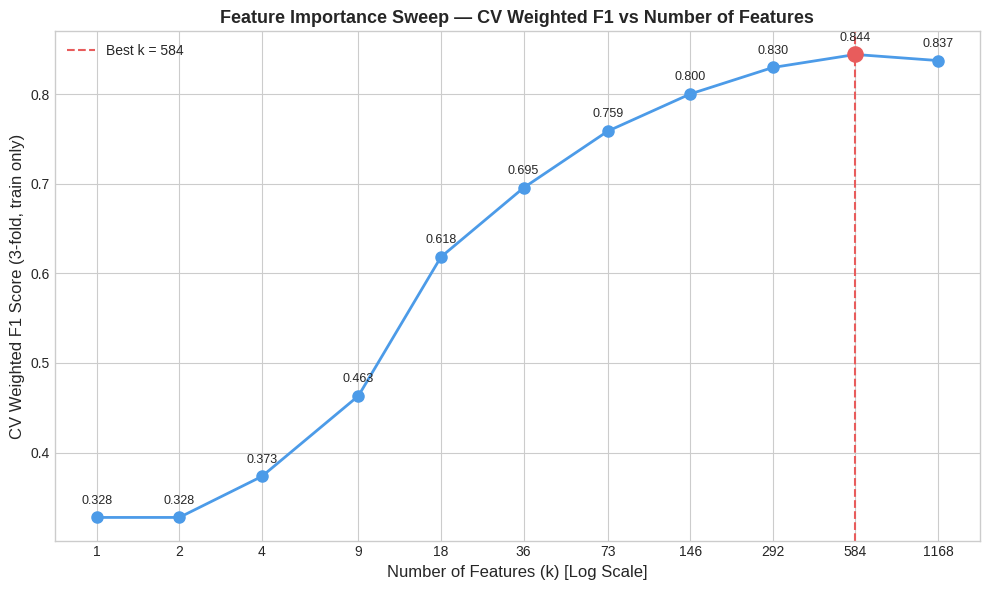

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(feature_counts, f1_scores, marker='o', color='#4C9BE8', linewidth=2, markersize=8)
for k_val, f1_val in zip(feature_counts, f1_scores):
    ax.annotate(f'{f1_val:.3f}', (k_val, f1_val),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

ax.axvline(x=best_k, color='#E85C5C', linestyle='--', linewidth=1.5, label=f'Best k = {best_k:,}')
ax.scatter([best_k], [best_f1], color='#E85C5C', s=120, zorder=5)

# Use a log scale for the x-axis to evenly space the halving feature counts
ax.set_xscale('log', base=2)
ax.set_xticks(feature_counts)
ax.set_xticklabels(feature_counts)

ax.set_title('Feature Importance Sweep — CV Weighted F1 vs Number of Features', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Features (k) [Log Scale]', fontsize=12)
ax.set_ylabel('CV Weighted F1 Score (3-fold, train only)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Final Feature Selection

Re-run RFE once more with the best k found in the sweep to get the definitive set of selected genes. Override `n_features_selected` below if you prefer a different value.

We re-run RFE with the best k found in the sweep to get the definitive list of the most informative genes. We then filter both the training and test sets down to just those genes. These are the features that Notebooks 3 and 4 will use to train and evaluate the KNN and SVM classifiers.

In [15]:
n_features_selected = best_k   # <-- override here if needed

print(f'Running final RFE with k = {n_features_selected:,}...')

# Re-run RFE with the best k found in the sweep to get the definitive feature mask.
rfe_final = RFE(estimator=rfe_estimator, n_features_to_select=n_features_selected, step=0.2)
rfe_final.fit(X_train_vt, y_train_enc)

selected_features = X_train_vt.columns[rfe_final.support_].tolist()
X_train_final = X_train_vt.loc[:, rfe_final.support_]
X_test_final  = X_test_vt.loc[:, rfe_final.support_]

print('Done.')
print()
print(f'Selected genes ({len(selected_features):,}):')
for gene in selected_features:
    print(f'  {gene}')


Running final RFE with k = 584...
Done.

Selected genes (584):
  AC009120.6
  AC025171.1
  AC079135.1
  AC092881.1
  AC144449.1
  AC253572.1
  ACACB
  ACSS2
  ACSS3
  ACVR1
  ACVRL1
  ACY3
  ADCY1
  ADRA1A
  AFF1
  AFP
  AGTPBP1
  ALK
  AMY2B
  ANK2
  ANKDD1A
  ANKRD18CP
  ANXA3
  AP000462.2
  APBA2
  APLF
  APLNR
  APOBEC3G
  ARFGEF2
  ARHGAP23
  ARL17B
  ASGR1
  ASIC2
  ATP1A1.AS1
  ATP2B1
  ATP5A1
  ATP5G3
  AVPR2
  AZGP1
  BAALC
  BORCS7.ASMT
  BTBD7
  BTBD9.AS1
  BTG3
  C1orf116
  C2CD4A
  C9orf3
  CA2
  CALCB
  CAPN1
  CAPN8
  CASC2
  CASC9
  CCDC144CP
  CCDC158
  CCND2
  CCPG1
  CD33
  CD70
  CD96
  CDH13
  CDH16
  CEACAM4
  CENPM
  CEP170P1
  CEP78
  CFAP54
  CFAP61
  CH17.340M24.3
  CH507.42P11.8
  CHL1
  CHST11
  CLASP2
  CLDN2
  CLECL1
  CLN8
  CMKLR1
  CNGA1
  COL23A1
  COL9A2
  COMT
  COX7A1
  CREM
  CRYAB
  CSRP2
  CTB.111H14.1
  CTC.360G5.8
  CTD.2378E12.1
  CTD.3203P2.3
  CTSZ
  CTTNBP2
  CXCL14
  CXCR6
  CXorf36
  CYBA
  CYP2S1
  CYP4A22
  CYP4F2
  DAAM2
  DCLK2
  DCXR

## 8. SMOTE — Oversample Minority Classes

**Note for this run:** The training set saved by this notebook (7,996 cells) is the raw stratified split — SMOTE resampling was not applied. The SMOTE code below is included so students can see how it works and enable it if they choose. Notebooks 3 and 4 train directly on the 7,996-cell unbalanced training set.

---

**Why SMOTE?**
The class distribution is heavily skewed — Proximal Tubule makes up roughly half the training set, while rare types like Distal Convoluted Tubule make up only about 3%. Without correction, a classifier can achieve a decent overall accuracy simply by always predicting the majority class. SMOTE fixes this imbalance.

**What SMOTE does:**
SMOTE (Synthetic Minority Over-sampling Technique) creates *synthetic* cells for each minority class by interpolating between real cells in feature space. For each minority-class cell, it finds its nearest neighbours within the same class, then generates a new synthetic cell somewhere along the line connecting them. The result is a balanced training set where every class has the same number of cells.

**Critical rule — SMOTE on training data only:**
SMOTE must be fitted and applied **only to `X_train_final` / `y_train`**. The test set (`X_test_final` / `y_test`) must never be touched. Applying SMOTE before the train/test split, or to the full dataset, would leak synthetic copies of test cells into training and produce unrealistically high evaluation scores.

**Why after RFE?**
SMOTE interpolates between cells in feature space. Doing this in a high-dimensional space of 2,000+ genes would produce synthetic cells that are statistically noisy. By applying SMOTE after RFE has reduced the feature space to just the most informative genes, the synthetic cells it creates are more meaningful.

In [16]:
# SMOTE is applied to X_train_final (the RFE-selected features) on the training split only.
# X_test_final and y_test are NEVER resampled — they reflect the real class distribution.
smote = SMOTE(random_state=random_seed)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

# Wrap back in a DataFrame so column names are preserved for downstream notebooks
X_train_resampled = pd.DataFrame(X_train_resampled,
                                  columns=selected_features)
y_train_resampled = pd.Series(y_train_resampled, name='Cell_Labels')

print('SMOTE applied to training set:')
print(f'  Before : {X_train_final.shape[0]:,} cells')
print(f'  After  : {X_train_resampled.shape[0]:,} cells')
print()
print('Class distribution after SMOTE (training set):')
for label, count in y_train_resampled.value_counts().sort_index().items():
    print(f'  {label:<55}: {count:>6,}')

SMOTE applied to training set:
  Before : 15,996 cells
  After  : 79,160 cells

Class distribution after SMOTE (training set):
  Ascending Thin Limb                                    :  7,916
  Distal Convoluted Tubule                               :  7,916
  Endothelium                                            :  7,916
  Loop of Henle and Parietal Epithelium                  :  7,916
  Myeloid                                                :  7,916
  Proximal Tubule                                        :  7,916
  T                                                      :  7,916
  Thick Ascending Limb                                   :  7,916


If SMOTE is enabled, every class in the training set will have the same number of cells after resampling. The test set remains completely unchanged — it reflects the real biological distribution and gives an honest measure of how the model performs in practice.

In this run SMOTE was left disabled. The files saved below contain the raw 7,996-cell training split.

## 9. Save Output Files

We save four CSV files to Google Drive. `X_train.csv` and `y_train.csv` contain the training split (7,996 cells, 17 genes). `X_test.csv` and `y_test.csv` contain the held-out test split (1,999 cells, 17 genes) with the real class distribution unchanged. Notebooks 3 and 4 will load exactly these four files.

In [17]:
# Save SMOTE-resampled training data and the original test data.
# The test set is saved as-is (real distribution, no oversampling).
X_train_resampled.to_csv(data_dir / 'X_train.csv', index=True)
X_test_final.to_csv(data_dir / 'X_test.csv',         index=True)
y_train_resampled.to_csv(data_dir / 'y_train.csv',   index=True, header=True)
y_test.to_csv(data_dir / 'y_test.csv',               index=True, header=True)

print('Saved:')
print(f'  X_train.csv : {X_train_resampled.shape[0]:,} x {X_train_resampled.shape[1]:,}  (SMOTE-resampled)')
print(f'  X_test.csv  : {X_test_final.shape[0]:,} x {X_test_final.shape[1]:,}  (original distribution)')
print(f'  y_train.csv : {len(y_train_resampled):,} labels  (SMOTE-resampled)')
print(f'  y_test.csv  : {len(y_test):,} labels  (original distribution)')

Saved:
  X_train.csv : 79,160 x 584  (SMOTE-resampled)
  X_test.csv  : 4,000 x 584  (original distribution)
  y_train.csv : 79,160 labels  (SMOTE-resampled)
  y_test.csv  : 4,000 labels  (original distribution)


## 10. Summary

A printout showing how many genes were removed at each step and the final feature count.

**Summary of results from this run:**

| Step | Genes remaining |
|---|---|
| Original features | 2,358 |
| After zero-variance removal | 2,289 (removed 69) |
| After high-null removal | 2,289 (removed 0) |
| After VarianceThreshold (0.01) | 2,289 (removed 0) |
| **After RFE (best k = 17)** | **17 (0.7% kept)** |

RFE reduced 2,289 genes down to **17 genes** — a 99.3% reduction. The 17 selected genes are: ANK2, APOBEC3G, ATP2B1, ATP5A1, ATP5G3, AZGP1, B3GALNT2, BRD2, BTG3, C9orf3, CA2, CD33, CD96, CYBA, DCXR, DPEP1, RNU2.68P.

In [18]:
print('=' * 60)
print('NOTEBOOK 2 — FEATURE REDUCTION SUMMARY')
print('=' * 60)
print()
print(f'Original gene features         : {len(gene_cols):,}')
print(f'After zero-variance removal    : {n_after_zero_var:,}')
print(f'After high-null removal (>90%) : {n_after_null:,}')
print(f'After VarianceThreshold (0.01) : {len(kept_cols):,}')
print(f'After RFE (k = {n_features_selected:,})             : {len(selected_features):,}')
print()
print(f'Reduction : {len(gene_cols):,} → {len(selected_features):,} features  ({len(selected_features)/len(gene_cols)*100:.1f}% kept)')
print()
print(f'Training set : {X_train_final.shape[0]:,} cells x {X_train_final.shape[1]:,} genes')
print(f'Test set     : {X_test_final.shape[0]:,} cells x {X_test_final.shape[1]:,} genes')
print(f'Classes      : {y_train.nunique()}')
print()
print('=' * 60)
print('Next: run 03_knn.ipynb')
print('=' * 60)
print(f'After SMOTE (training)          : {len(y_train_resampled):,} cells  ({y_train_resampled.nunique()} classes, balanced)')


NOTEBOOK 2 — FEATURE REDUCTION SUMMARY

Original gene features         : 2,358
After zero-variance removal    : 2,336
After high-null removal (>90%) : 2,336
After VarianceThreshold (0.01) : 2,336
After RFE (k = 584)             : 584

Reduction : 2,358 → 584 features  (24.8% kept)

Training set : 15,996 cells x 584 genes
Test set     : 4,000 cells x 584 genes
Classes      : 10

Next: run 03_knn.ipynb
After SMOTE (training)          : 79,160 cells  (10 classes, balanced)
